## Demonstrate fast search and parameter estimation of MBHB 
- Data: TDC II-0.2, the TDI-combined version ([data](https://zenodo.org/records/15469724/files/0_2_MBHB_TDIXYZ.h5?download=1), [parameters](https://zenodo.org/records/15532090/files/0_2_MBHB_parameters.h5?download=1)) 
- Template: TDI-2.0 response of ``IMRPhenomD`` waveform (implemented in ``WF4PY``) 
- Method: $\mathcal{F}$-statistics, differential evolution optimization, nested sampling via ``NESSAI``      
This example represents an idealized scenario where there is only one bright MBHB in the data. 

In [42]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import bilby     
# import logging
# bilby.core.utils.logger.setLevel(logging.ERROR)

import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *


import multiprocessing

# 在 Notebook 环境中，防止重复设置启动方法导致报错
try:
    multiprocessing.set_start_method("fork")
except RuntimeError:
    # 如果已经设置过，忽略错误，通常在Notebook中这是正常的
    pass

#import multiprocessing
#if __name__=='__main__':
#    multiprocessing.set_start_method("fork")

In [43]:
DATA_DIR = "/home/sci_77/miniconda3/envs/tri_env/lib/Triangle-BBH-main/Triangle-BBH-main/Examples/0_2_MBHB_TDIXYZ.h5" 
PARAM_DIR = "/home/sci_77/miniconda3/envs/tri_env/lib/Triangle-BBH-main/Triangle-BBH-main/Examples/0_2_MBHB_parameters.h5"

ORBIT_DIR = "/home/sci_77/miniconda3/lib/Triangle-Simulator-master/OrbitData/MicroSateOrbitEclipticTCB"

## Load data 

In [44]:
# the path of TDC data 
with h5py.File(DATA_DIR, "r") as h5file: 
    read_dict = read_dict_from_h5(h5file["/"])
    
# the path of parameters 
with h5py.File(PARAM_DIR, "r") as h5file: 
    injected_parameters = read_dict_from_h5(h5file["/"])
    
read_dict.keys(), injected_parameters.keys()

(dict_keys(['XYZ', 'time']),
 dict_keys(['chirp_mass', 'coalescence_phase', 'coalescence_time', 'inclination', 'latitude', 'longitude', 'luminosity_distance', 'mass_ratio', 'psi', 'spin_1z', 'spin_2z']))

### Combine AET and slice data near merger 
Assume that the merger time is roughly located (e.g. by whitening and examining the peak in time-domain data)

In [45]:
data_time = read_dict["time"]
A2_td, E2_td, _ = AETfromXYZ(read_dict["XYZ"]["X2"], read_dict["XYZ"]["Y2"], read_dict["XYZ"]["Z2"])
data_channels_td = -np.array([A2_td, E2_td]) # the convension of Michelson TDI-2.0 is different from Triangle-Simulator by a minus sign
channel_names = ["A2", "E2"] 

# time_idx = np.where(np.abs(data_time/DAY - injected_parameters["coalescence_time"])<1.5)[0]
time_idx = np.where((data_time/DAY - injected_parameters["coalescence_time"]<1) & (data_time/DAY - injected_parameters["coalescence_time"]>-4))[0]
data_time = data_time[time_idx]
data_channels_td = data_channels_td[:, time_idx]

dt = data_time[1] - data_time[0]
Tobs = len(data_time) * dt 
print(dt)
print(len(data_time))
coa_time = injected_parameters["coalescence_time"]
print(coa_time)

10.0
43199
25.0


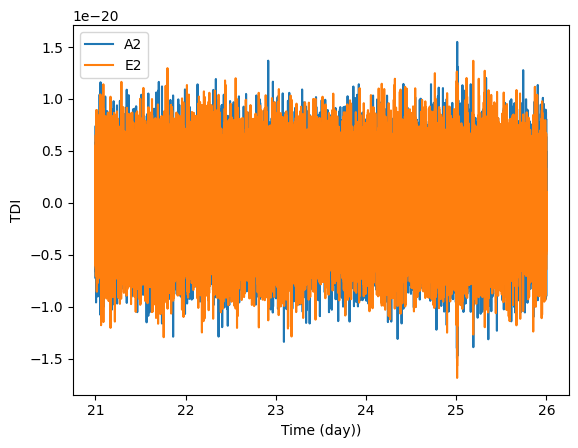

In [46]:
for i in range(len(data_channels_td)): 
    plt.plot(data_time/DAY, data_channels_td[i], label=channel_names[i])
plt.xlabel("Time (day))")
plt.ylabel("TDI")
plt.legend()

### Fourier transform 

In [47]:
data_channels_fd = [] 
for i in range(len(data_channels_td)): 
    ff, xf = FFT_window(
        data_array=data_channels_td[i], 
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=1000./Tobs)
    )
    data_channels_fd.append(xf) 
data_channels_fd = np.array(data_channels_fd) * np.exp(-TWOPI * 1.j * ff * data_time[0]) # shift to the "correct" time 
data_frequency = ff 

### Estimate noise PSD

In [48]:
ff, A2_PSD = PSD_window(
    data_array=A2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)
ff, E2_PSD = PSD_window(
    data_array=E2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)

psd_func_A2 = CubicSpline(ff, A2_PSD, extrapolate=True)
psd_func_E2 = CubicSpline(ff, E2_PSD, extrapolate=True)
psd_channels = np.array([
    psd_func_A2(data_frequency), 
    psd_func_E2(data_frequency)
])

/tmp/ipykernel_1806/2290969887.py:3: RuntimeWarning: invalid value encountered in sqrt
  plt.loglog(data_frequency, np.sqrt(psd_channels[i] * Tobs / 2.), linestyle="--", label=channel_names[i]+" noise level")


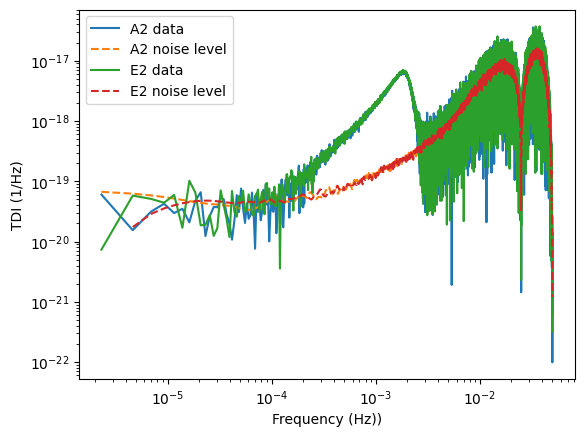

In [49]:
for i in range(len(data_channels_fd)): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data")
    plt.loglog(data_frequency, np.sqrt(psd_channels[i] * Tobs / 2.), linestyle="--", label=channel_names[i]+" noise level")
plt.xlabel("Frequency (Hz))")
plt.ylabel("TDI (1/Hz)")
plt.legend()

In [68]:
FMIN = 0.5e-4 
FMAX = 1e-2 
freq_idx = np.where((data_frequency>=FMIN)&(data_frequency<=FMAX))[0]
data_frequency = data_frequency[freq_idx]
data_channels_fd = data_channels_fd[:, freq_idx]
psd_channels = psd_channels[:, freq_idx]

## Models 

### waveform, response and noise

In [69]:
orbit = Orbit(OrbitDir=ORBIT_DIR)

# initialize  waveform generator 
WFG = WaveformGeneratorFRef(mode="primary")

# initialize response generator 
FDTDI = FDTDIResponseGeneratorFRef(orbit_class=orbit, waveform_generator=WFG)

# response settings 
response_kwargs_interp = dict(
    fmin=FMIN, 
    fmax=FMAX,
    fref=1e-3,
    modes=[(2,2),], 
    tmin=data_time[0]/DAY,
    tmax=data_time[-1]/DAY, 
    tref_at_constellation=True, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method='cubic',
)

response_kwargs_direct = response_kwargs_interp.copy()
response_kwargs_direct["interpolation_method"] = None 

# covariance matrix
CovMat = np.array([
    [psd_channels[0], np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), psd_channels[1]],
]) / 4. * Tobs 

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) 

response_kwargs_interp, InvCovMat.shape 

({'fmin': 5e-05,
  'fmax': 0.01,
  'fref': 0.001,
  'modes': [(2, 2)],
  'tmin': 21.00011574074074,
  'tmax': 25.99988425925926,
  'tref_at_constellation': True,
  'TDIGeneration': '2nd',
  'optimal_combination': True,
  'drop_T': True,
  'interpolation_method': 'cubic'},
 (4298, 2, 2))

In [70]:
injected_parameters_fref = injected_parameters.copy()
injected_parameters_fref["reference_time"] = injected_parameters["coalescence_time"]
injected_parameters_fref["reference_phase"] = injected_parameters["coalescence_phase"]
injected_parameters_fref.pop("coalescence_time")
injected_parameters_fref.pop("coalescence_phase")
injected_parameters_fref

{'chirp_mass': 3000000.0,
 'inclination': 1.2566370614359172,
 'latitude': 0.5235987755982988,
 'longitude': 4.71238898038469,
 'luminosity_distance': 47689.47472418477,
 'mass_ratio': 0.25,
 'psi': 0.9424777960769379,
 'spin_1z': 0.4,
 'spin_2z': 0.6,
 'reference_time': 25.0,
 'reference_phase': 1.0471975511965976}

## Search high-likelihood parameters with $\mathcal{F}$-statistics

### set priors for the "intrinsic" parameters (dimension = 11 - 4)

In [71]:
lgMc_prior = [5., 7.]
q_prior = [0.01, 0.99]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [response_kwargs_direct["tmin"], response_kwargs_direct["tmax"]]
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

### initialize $\mathcal{F}$-statitsitcs

In [72]:
Fstat = FstatisticsFref(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_interp, 
    use_gpu=False, 
)

### search in prior 

In [73]:
def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams), normalized to (0, 1)
    """
    try: 
        int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nparams)
        params_in = Fstat.IntParamArr2ParamDict(int_params) # (Nparams) -> dictionary
        return -Fstat.calculate_Fstat(intrinsic_parameters=params_in) # float
    except np.linalg.LinAlgError:
        return np.infty 

n_dim_int = 7 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    maxiter=1000,
    popsize=5*n_dim_int,
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=False,
    workers=-1, 
)

DE_result

/home/sci_77/miniconda3/envs/tri_env/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


             message: Optimization terminated successfully.
             success: True
                 fun: -595034.7240309203
                   x: [ 7.384e-01  2.458e-01  7.175e-01  8.516e-01
                        7.995e-01  7.409e-01  5.703e-01]
                 nit: 163
                nfev: 40180
          population: [[ 7.384e-01  2.458e-01 ...  7.409e-01  5.703e-01]
                       [ 7.384e-01  2.449e-01 ...  7.478e-01  6.148e-01]
                       ...
                       [ 7.384e-01  2.456e-01 ...  7.455e-01  5.499e-01]
                       [ 7.385e-01  2.465e-01 ...  7.409e-01  6.135e-01]]
 population_energies: [-5.950e+05 -5.950e+05 ... -5.950e+05 -5.950e+05]

### Reconstruct other parameters and waveform 

In [74]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = Fstat.calculate_Fstat(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic(searched_a)
searched_parameters = dict(searched_int_params, **searched_ext_params)

searched_wf = FDTDI.Response(
    searched_parameters, 
    data_frequency, 
    **response_kwargs_interp, 
)

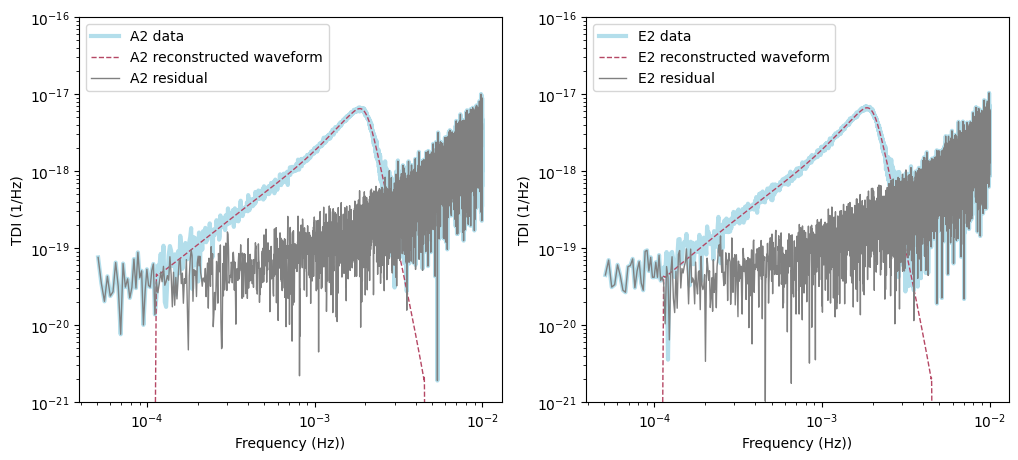

In [75]:
plt.figure(figsize=(12, 5))
for i in range(len(data_channels_fd)): 
    plt.subplot(121+i)
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data", color=BLUE, linewidth=3, alpha=0.5)
    plt.loglog(data_frequency, np.abs(searched_wf[i]), label=channel_names[i]+" reconstructed waveform", color=RED, linewidth=1, linestyle="--")
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]-searched_wf[i]), label=channel_names[i]+" residual", color="grey", linewidth=1)
    plt.xlabel("Frequency (Hz))")
    plt.ylabel("TDI (1/Hz)")
    plt.legend(loc="upper left")
    plt.ylim(1e-21, 1e-16)

## Fisher analysis around the searched parameters 

In [76]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        parameters=param_dict, 
        freqs=np.array(frequencies),  
        **response_kwargs_interp, 
    )
    return res

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'reference_time': 0.001,
    'reference_phase': 0.01,
    'luminosity_distance': 10.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=searched_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequency, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 2141.7352948248567,
 'mass_ratio': 0.0012367461253975243,
 'spin_1z': 0.007831204559130134,
 'spin_2z': 0.03531390086156921,
 'reference_time': 7.944009085315752e-06,
 'reference_phase': 0.0036327214275528024,
 'luminosity_distance': 4812.263627300392,
 'inclination': 0.004571309963690727,
 'longitude': 0.20141894790942086,
 'latitude': 0.25989182698152585,
 'psi': 0.08502808917759003}

- $t_{\rm ref}$ and $\varphi_{\rm ref}$ can not be closed to the injected value due to different definitions
- sky position, inclination and polarization angle may not be closed to the injected value due to multi-modality of the posterior surface

In [77]:
searched_parameters_reflected = get_reflected_parameter_dict_Fref(searched_params=searched_parameters, orbit=orbit)
print("parameter | searched deviation | searched (reflected mode) deviation | FIM bound")
for key in injected_parameters_fref.keys(): 
    print(key, np.abs(injected_parameters_fref[key]-searched_parameters[key]), np.abs(injected_parameters_fref[key]-searched_parameters_reflected[key]), FIM.param_errors[key])

parameter | searched deviation | searched (reflected mode) deviation | FIM bound
chirp_mass 2347.9590498050675 2347.9590498050675 2141.7352948248567
inclination 0.0008608838849408773 0.6274576468330177 0.004571309963690727
latitude 0.3826309301530741 1.3633904176173404 0.25989182698152585
longitude 0.057217063278683256 2.4027466895597875 0.20141894790942086
luminosity_distance 4263.055335805693 4263.055335805693 4812.263627300392
mass_ratio 0.0008465864244561749 0.0008465864244561749 0.0012367461253975243
psi 0.023301206479007575 0.817893256313607 0.08502808917759003
spin_1z 0.008431172365020556 0.008431172365020556 0.007831204559130134
spin_2z 0.03280323529986218 0.03280323529986218 0.03531390086156921
reference_time 0.0023830667834801034 0.0023830667834801034 7.944009085315752e-06
reference_phase 1.8234619097435234 1.8234619097435234 0.0036327214275528024


the waveforms corresponding to searched parameter and its reflection are shown below 

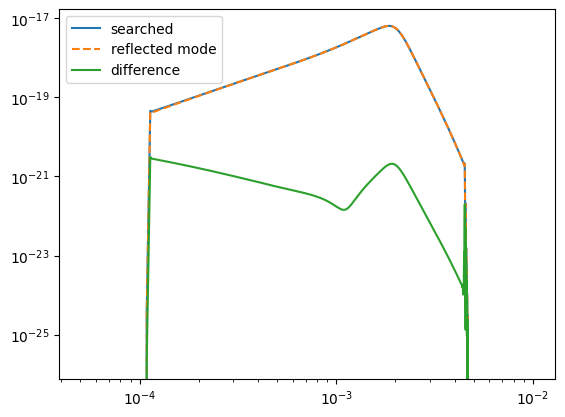

In [78]:
searched_wf_ref = FDTDI.Response(
    searched_parameters_reflected, 
    data_frequency, 
    **response_kwargs_interp, 
)
plt.loglog(data_frequency, np.abs(searched_wf[0]), label="searched")
plt.loglog(data_frequency, np.abs(searched_wf_ref[0]), linestyle="--", label="reflected mode")
plt.loglog(data_frequency, np.abs(searched_wf_ref[0]-searched_wf[0]), label="difference")
plt.legend()

## Likelihood

### initialize heterodyned likelihood 

In [79]:
Like = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_direct, 
    Fref_waveform=True, 
    use_gpu=False,
)

Like.prepare_het_log_like(base_parameters=ParamDict2ParamArrFref(searched_parameters))

### create bilby wrapper 

In [80]:

class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="heterodyned"):
        """ 
            type can be "heterodyned" or "full"
        """
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        self.like_type = type 

    def log_likelihood(self):
        if self.like_type == "heterodyned": 
            # convert to single precision to avoid instability of the sampler
            # return np.float32(Like.het_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters)))
            return Like.het_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))
        else: 
            return Like.full_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters))

## Prior 

In [81]:
# set prior to be 10 sigma around the truths 
priors = bilby.core.prior.PriorDict()
priors["chirp_mass"] = bilby.prior.Uniform(minimum=searched_parameters["chirp_mass"]-5.*FIM.param_errors["chirp_mass"], maximum=searched_parameters["chirp_mass"]+5.*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, searched_parameters["mass_ratio"]-5.*FIM.param_errors["mass_ratio"]), maximum=min(0.99, searched_parameters["mass_ratio"]+5.*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_parameters["spin_1z"]-5.*FIM.param_errors["spin_1z"]), maximum=min(0.9, searched_parameters["spin_1z"]+5.*FIM.param_errors["spin_1z"]), name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_parameters["spin_2z"]-5.*FIM.param_errors["spin_2z"]), maximum=min(0.9, searched_parameters["spin_2z"]+5.*FIM.param_errors["spin_2z"]), name="spin_2z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=searched_parameters["reference_time"]-5.*FIM.param_errors["reference_time"], maximum=searched_parameters["reference_time"]+5.*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(6e3, searched_parameters["luminosity_distance"]-5.*FIM.param_errors["luminosity_distance"]), maximum=min(1e5, searched_parameters["luminosity_distance"]+5.*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

# for param_name in ["chirp_mass", "mass_ratio", "spin_1z", "spin_2z"]: 
#     priors[param_name] = searched_parameters[param_name]

priors

{'chirp_mass': Uniform(minimum=2986943.3644760707, maximum=3008360.717424319, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.24466285579746855, maximum=0.2570303170514438, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': Uniform(minimum=0.3524128048393288, maximum=0.43072485043063014, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None),
 'spin_2z': Uniform(minimum=0.45623373099201614, maximum=0.8093727396077082, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None),
 'reference_time': Uniform(minimum=24.997577213171095, maximum=24.997656653261945, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None),
 'reference_phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', latex_label='$\\varphi_\\mathrm{ref}$', unit=None, boundary='periodic'),
 'luminosity_distance': Uniform(minimum=19365.10125187712, maximum=67487

## Run nested sampling 

In [82]:
# the parameterization of time and phase parameters are different, so we set the truths of these two parameters to None 
show_parameters = injected_parameters_fref.copy()
show_parameters["reference_time"] = None 
show_parameters["reference_phase"] = None 

In [84]:
BLike = bilby_likelihood_wrapper()

ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

result = bilby.run_sampler(
    likelihood=BLike, 
    priors=priors,
    sampler="nessai", 
    nlive=1000,
    stopping=0.5, 
    npool=ncpu, # use all cpus 
    injection_parameters=injected_parameters, 
    outdir="Samples",
    label="vmbhb_example",
    plot=True,
    resume=False, 
    # resume=True, 
)

12:32 bilby INFO    : Running for label 'vmbhb_example', output will be saved to 'Samples'


number of cpus = 12


12:32 bilby INFO    : Analysis priors:
12:32 bilby INFO    : chirp_mass=Uniform(minimum=2986943.3644760707, maximum=3008360.717424319, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
12:32 bilby INFO    : mass_ratio=Uniform(minimum=0.24466285579746855, maximum=0.2570303170514438, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
12:32 bilby INFO    : spin_1z=Uniform(minimum=0.3524128048393288, maximum=0.43072485043063014, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None)
12:32 bilby INFO    : spin_2z=Uniform(minimum=0.45623373099201614, maximum=0.8093727396077082, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None)
12:32 bilby INFO    : reference_time=Uniform(minimum=24.997577213171095, maximum=24.997656653261945, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None)
12:32 bilby INFO    : reference_phase=Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', lat

04-01 12:32 nessai INFO    : Running Nessai version 0.15.2
04-01 12:32 nessai INFO    : Starting multiprocessing pool with 12 processes


/home/sci_77/miniconda3/envs/tri_env/lib/python3.9/site-packages/nessai/utils/logging.py:133: FutureWarning: setup_logger is deprecated, use configure_logger instead
  warnings.warn(


04-01 12:32 nessai INFO    : Initialising nested sampler
04-01 12:32 nessai WARNING : Multiprocessing pool has already been configured.
04-01 12:32 nessai WARNING : Removing unused keyword arguments ({'step_kwargs', 'step_type', 'n_accept', 'n_marg', 'plot_chain', 'generate_augment', 'augment_dims', 'n_steps', 'plot_history', 'max_n_clusters', 'marginalise_augment', 'ensemble_fraction'}) from kwargs for FlowProposal. These are valid keyword arguments but correspond to other proposal classes.
04-01 12:32 nessai INFO    : Passing kwargs to FlowProposal: {'enforce_likelihood_threshold': False, 'training_config': None, 'poolsize': 1000, 'check_acceptance': False, 'max_poolsize_scale': 10, 'update_poolsize': True, 'accumulate_weights': False, 'save_training_data': False, 'reparameterisations': None, 'fallback_reparameterisation': 'zscore', 'use_default_reparameterisations': None, 'reverse_reparameterisations': False, 'map_to_unit_hypercube': False, 'latent_prior': 'truncated_gaussian', 'lat

14:20 bilby INFO    : Sampling time: 1 day, 1:46:45.385293
14:20 bilby INFO    : Summary of results:
nsamples: 1850
ln_noise_evidence:    nan
ln_evidence: 594985.848 +/-  0.202
ln_bayes_factor:    nan +/-  0.202



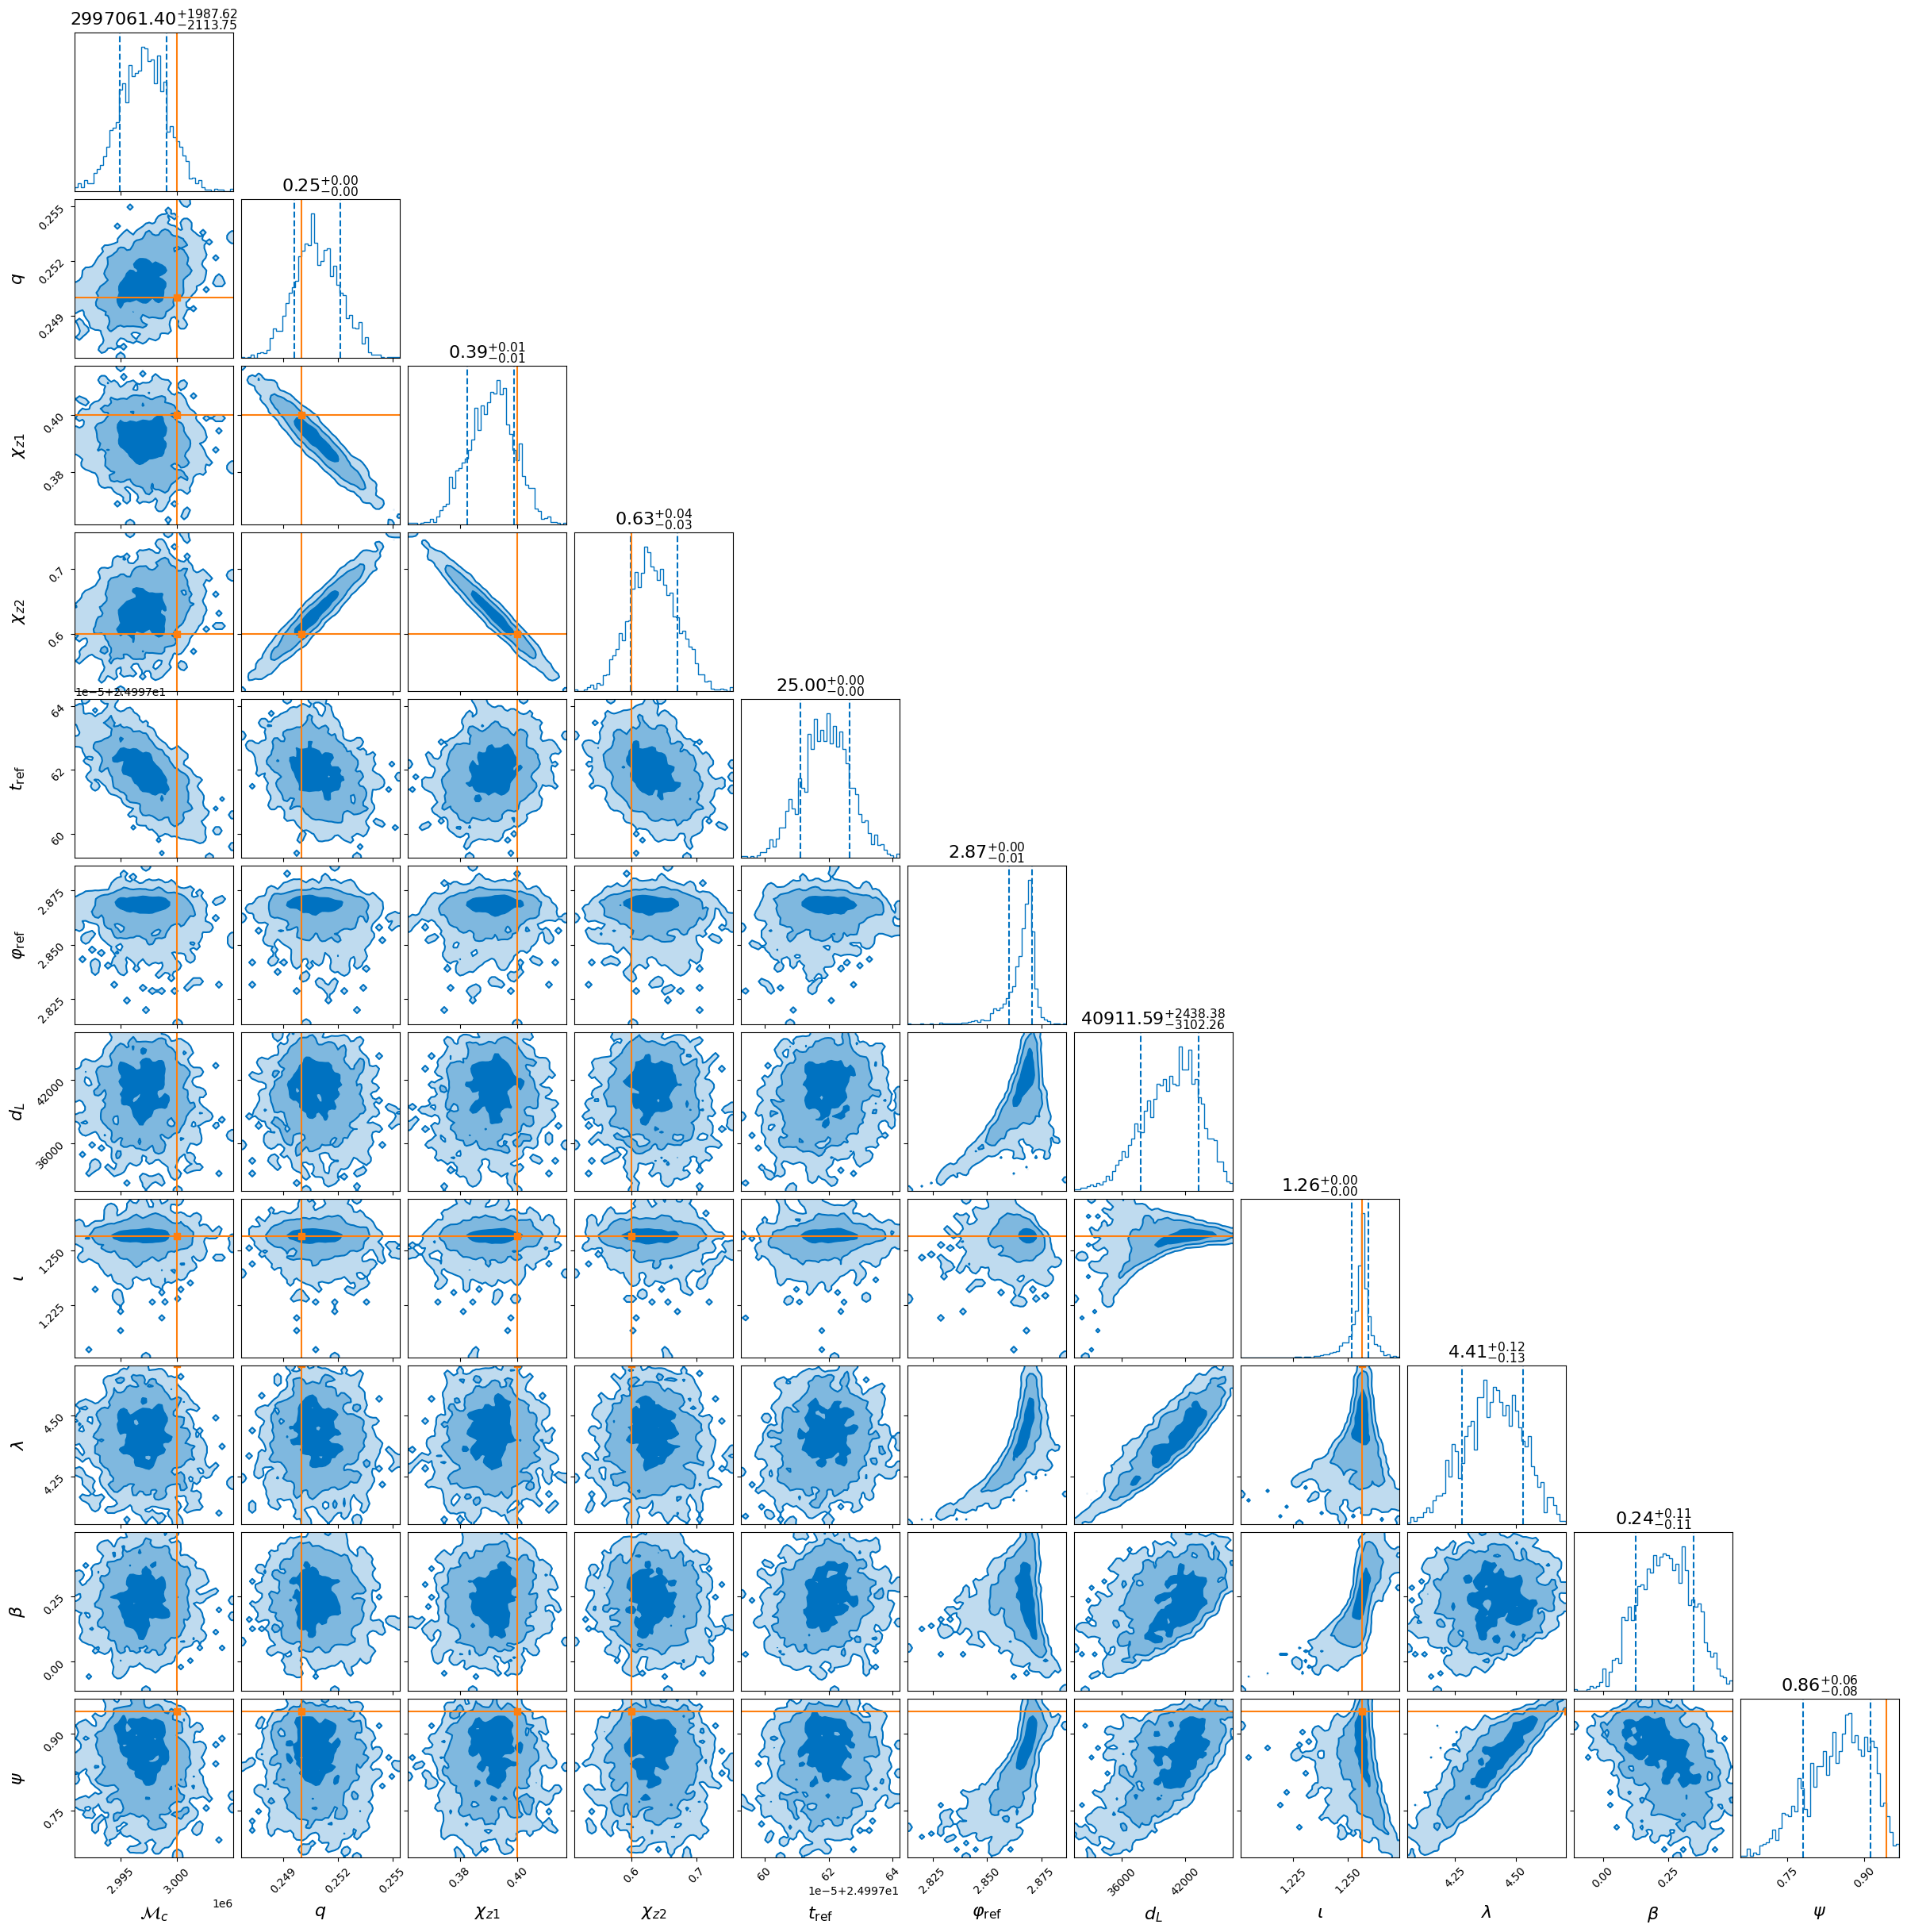

In [85]:
result.plot_corner(save=True)

### Some insights based on the posterior: 
- multi-modality of sky position, inclination, and polarization angle (reflected mode) $\rightarrow$ potential of wrong localization using MLE 
- multi-modality of phase parameter due to the exclusion of higher-order modes 
- verification of the consistency between time-domain respoonse (TDC II-0.2 data, generated using Triangle-Simulator) and frequency-domain response (Triangle-BBH) for this case 
- compare with Fisher analysis

In [86]:
searched_parameters_reflected = get_reflected_parameter_dict_Fref(searched_params=searched_parameters, orbit=orbit)
print("parameter | true | searched | searched (reflected)")
for pn in ["inclination", "longitude", "latitude"]:
    print(pn, injected_parameters[pn], searched_parameters[pn], searched_parameters_reflected[pn])

parameter | true | searched | searched (reflected)
inclination 1.2566370614359172 1.2574979453208581 1.884094708268935
longitude 4.71238898038469 4.655171917106006 2.309642290824902
latitude 0.5235987755982988 0.14096784544522473 -0.8397916420190416
